In [1]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import json
import pandas as pd

ROOT_FOLDER = Path("../data/raw")

extensions = {".jpg"}

In [2]:
TRAIN_FOLDER = ROOT_FOLDER/"train"

n_images_train = sum(1 for file in TRAIN_FOLDER.iterdir()
                     if file.is_file() and file.suffix.lower() in extensions)

print(f"Number of training images : {n_images_train}")

Number of training images : 2630


In [3]:
TEST_FOLDER = ROOT_FOLDER/"test"

n_images_test = sum(1 for file in TEST_FOLDER.iterdir()
                     if file.is_file() and file.suffix.lower() in extensions)

print(f"Number of test images : {n_images_test}")

Number of test images : 531


In [4]:
VAL_FOLDER = ROOT_FOLDER/"val"

n_images_val = sum(1 for file in VAL_FOLDER.iterdir()
                     if file.is_file() and file.suffix.lower() in extensions)

print(f"Number of evalution images : {n_images_val}")

Number of evalution images : 516


In [5]:
list(Path("../data/raw/train").iterdir())[:3]

[PosixPath('../data/raw/train/2050984554.jpg'),
 PosixPath('../data/raw/train/527901046+-1046.jpg'),
 PosixPath('../data/raw/train/2073487737.jpg')]

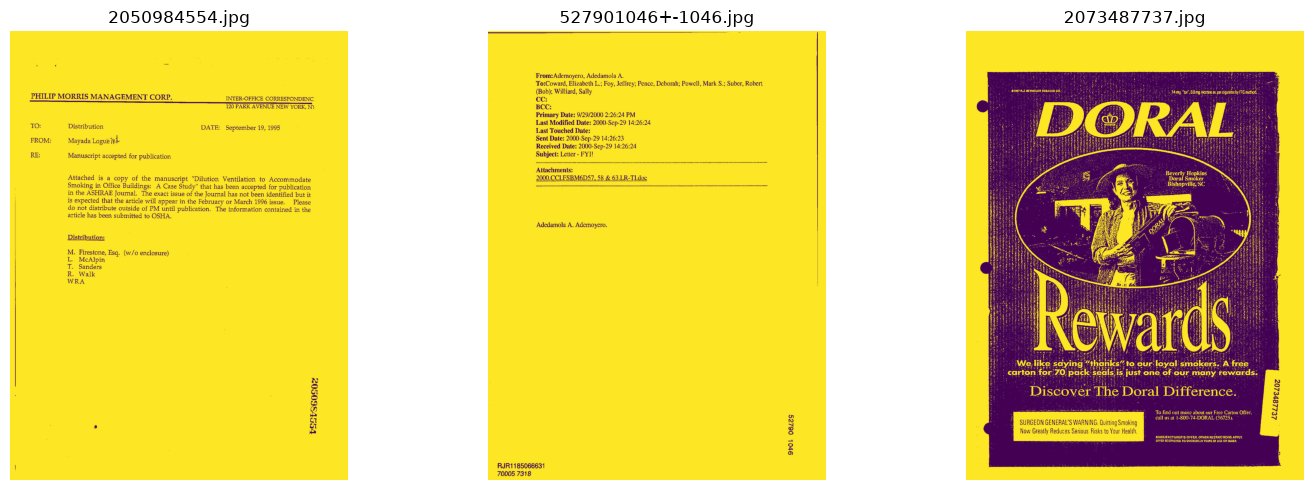

In [6]:
images_train = [
    file for file in TRAIN_FOLDER.rglob("*")
    if file.is_file() and file.suffix.lower() in extensions
][:3]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, image_path in zip(axes, images_train):
    image = Image.open(image_path)
    ax.imshow(image)
    ax.set_title(image_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

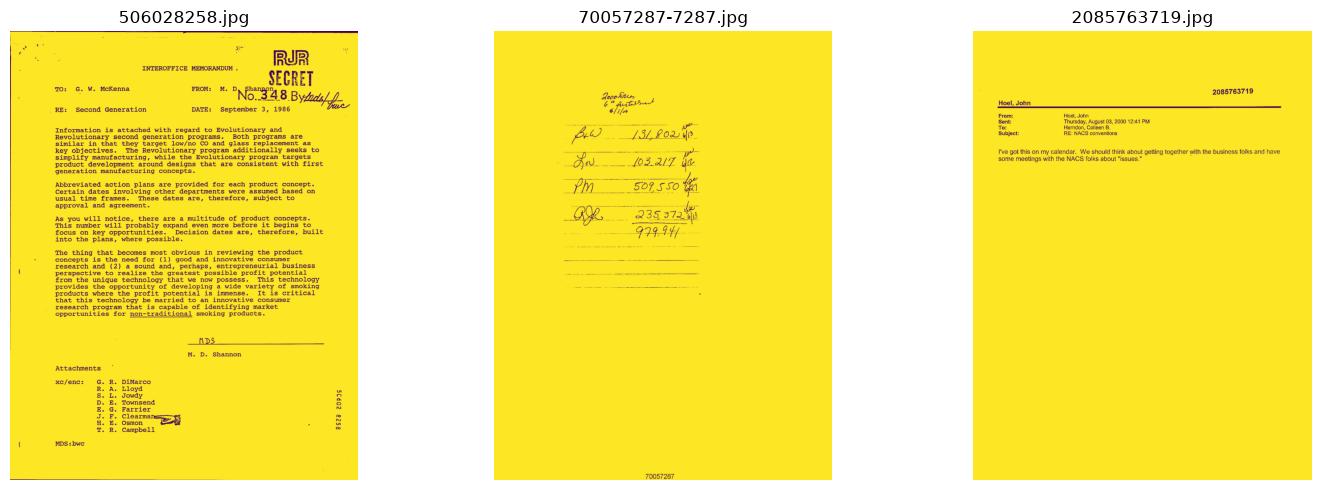

In [7]:
images_test = [
    file for file in TEST_FOLDER.rglob("*")
    if file.is_file() and file.suffix.lower() in extensions
][:3]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, image_path in zip(axes, images_test):
    image = Image.open(image_path)
    ax.imshow(image)
    ax.set_title(image_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

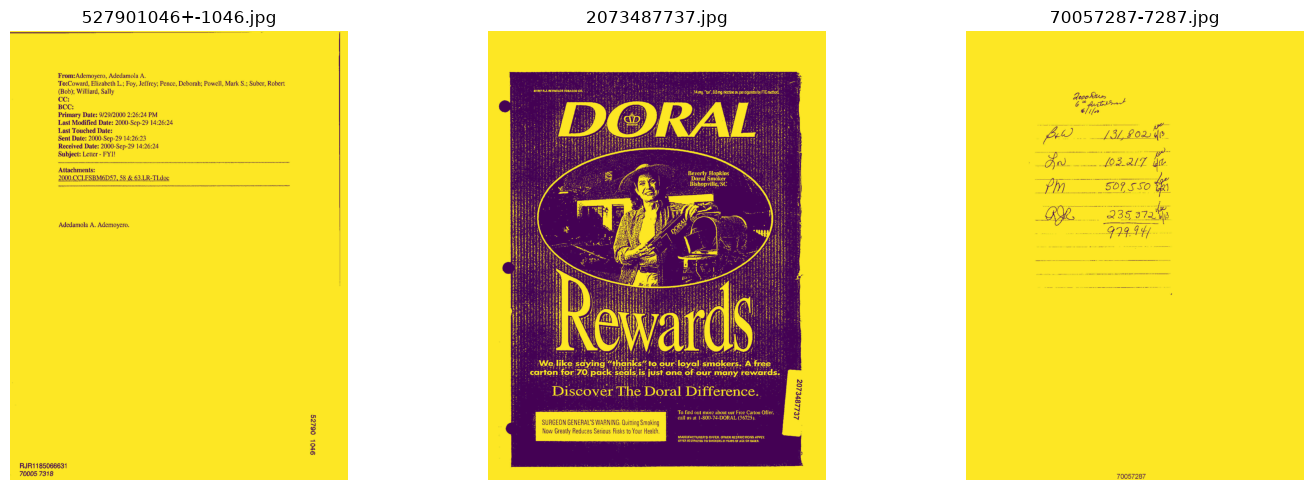

In [8]:
images_val = [
    file for file in VAL_FOLDER.rglob("*")
    if file.is_file() and file.suffix.lower() in extensions
][:3]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, image_path in zip(axes, images_val):
    image = Image.open(image_path)
    ax.imshow(image)
    ax.set_title(image_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
df_train = pd.read_json(TRAIN_FOLDER/"metadata.jsonl", lines = True)
df_train.head(3)

,file_name,label,label_id,text
0,12963987.jpg,Note,6,Shue. 135 io a te 4656861 44 465686144 PRODUCE...
1,503999149+-9150.jpg,Report,1,SAMPLING/FIELD MARKETING OPERATIONS WEEKLY STA...
2,2054647558.jpg,Form,8,Xe PHILIP MORRIS USA RECORDS RETENTION SCHEDUL...


In [10]:
df_train["label"].unique()

<StringArray>
[      'Note',     'Report',       'Form',       'ADVE',       'Memo',
      'Email',       'News',     'Letter',     'Resume', 'Scientific']
Length: 10, dtype: str

In [14]:
df_train["label"].value_counts()

label
Email         452
Memo          376
Letter        304
Form          249
Report        200
ADVE          157
News          148
Note          132
Resume         96
Scientific     72
Name: count, dtype: int64

In [16]:
df_test = pd.read_json(TEST_FOLDER/"metadata.jsonl", lines = True)
df_test.head(3)

,file_name,label,label_id,text
0,0000940821.jpg,News,5,"By William Safire WASHINGTON, May 15—Carmine D..."
1,2016003493.jpg,News,5,"HUDSON, MASS. SUN — D. 8,720: — BOSTON METROPO..."
2,2046593592.jpg,News,5,"-19- APR 1 9 196 b THE NEW YORK TIMES, WEDNESD..."


In [17]:
df_test["label"].unique()

<StringArray>
[      'News',       'ADVE',     'Resume',       'Form',     'Letter',
       'Note',       'Memo',     'Report',      'Email', 'Scientific']
Length: 10, dtype: str

In [18]:
df_test["label"].value_counts()

label
Email         57
Memo          48
Letter        38
Form          32
Report        26
ADVE          20
News          19
Note          17
Resume        13
Scientific     9
Name: count, dtype: int64

In [19]:
df_val = pd.read_json(VAL_FOLDER/"metadata.jsonl", lines = True)
df_val.head(3)

,file_name,label,label_id,text
0,2083780285.jpg,News,5,uI-099 {re POT FON) QU LAC GRC (e928 Se soe. (...
1,2025028981-e.jpg,News,5,"Tobacco News, a publication of the Tobacco ins..."
2,2026167362.jpg,News,5,a v 3. ADVERTISING / By Aux M. Fearoman. ‘De-N...


In [20]:
df_val["label"].unique()

<StringArray>
[      'News',     'Letter',       'ADVE',       'Memo',      'Email',
       'Form',     'Report',     'Resume',       'Note', 'Scientific']
Length: 10, dtype: str

In [21]:
df_val["label"].value_counts()

label
Email         56
Memo          47
Letter        38
Form          31
Report        25
ADVE          20
News          18
Note          16
Resume        12
Scientific     9
Name: count, dtype: int64